# 05 · Análisis de resultados

Lee los resultados guardados por los notebooks 02 y 04 (no reentrena
nada) y construye las tablas/gráficas finales para el README y la
presentación: ¿mejora el predictor al añadir historia sintética?, ¿qué
generador funciona mejor?, ¿coincide con qué generador preserva mejor la
distribución conjunta real (notebook 02)?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, plotting as pl

## 1. Cargar resultados

In [2]:
results = pd.read_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
corr_quality = pd.read_csv(config.TABLES_DIR / "02_calidad_correlacion_generadores.csv", index_col=0)
empalme = pd.read_csv(config.TABLES_DIR / "03_continuidad_empalme.csv", index_col=0)
results.head()

,Unnamed: 0,generator,synth_years,n_train,pct_synth,mse,mae,directional_accuracy
0,0,solo_reales,0,1145,0.000000,0.000291,0.012729,0.501967
1,1,gan,6,2655,0.568738,0.000281,0.012397,0.531475
2,2,gaussian,6,2655,0.568738,0.000261,0.011928,0.539344
3,3,noise,6,2655,0.568738,0.000252,0.011790,0.523934
4,4,rbig,6,2655,0.568738,0.000251,0.011803,0.509836


## 2. Tabla final: MAE por generador y años de backfill sintético añadidos

`synth_years=0` es la referencia "solo reales": en ese punto los 4
generadores entrenan exactamente con los mismos datos (todavía no se ha
añadido ningún día sintético), así que comparten valor. Se construye la
tabla con esa fila replicada para las 4 columnas — en vez de dejar una
columna `solo_reales` suelta que solo tendría dato en la fila 0 y dejaría
el resto de la tabla lleno de huecos.

In [3]:
GENERADORES = [g for g in results["generator"].unique() if g != "solo_reales"]
baseline = results[results["generator"] == "solo_reales"].iloc[0]
baseline_mae = baseline["mae"]


def pivot_con_baseline(metric: str) -> pd.DataFrame:
    """Pivot (synth_years x generador) de `metric`, con la fila
    synth_years=0 rellenada con el valor de referencia 'solo reales' para
    los 4 generadores (en ese punto son el mismo modelo)."""
    piv = (
        results[results["generator"] != "solo_reales"]
        .pivot_table(index="synth_years", columns="generator", values=metric)
    )
    piv.loc[0] = baseline[metric]
    return piv.sort_index()[GENERADORES]


pivot_mae = pivot_con_baseline("mae")
pivot_dir = pivot_con_baseline("directional_accuracy")
mejora_pct = (baseline_mae - pivot_mae) / baseline_mae * 100

pivot_mae.to_csv(config.TABLES_DIR / "05_tabla_mae_final.csv")
pivot_dir.to_csv(config.TABLES_DIR / "05_tabla_precision_direccional.csv")
mejora_pct.to_csv(config.TABLES_DIR / "05_tabla_mejora_pct.csv")

print(
    "Referencia 'solo reales' (synth_years=0, ~4,6 años reales sin sintéticos): "
    f"MAE {baseline_mae:.5f} | precisión direccional {baseline['directional_accuracy']:.1%}"
)
pivot_mae.round(5)

Referencia 'solo reales' (synth_years=0, ~4,6 años reales sin sintéticos): MAE 0.01273 | precisión direccional 50.2%


generator,gan,gaussian,noise,rbig
synth_years,,,,
0,0.01273,0.01273,0.01273,0.01273
6,0.01240,0.01193,0.01179,0.01180
12,0.01337,0.01253,0.01197,0.01178
18,0.01183,0.01183,0.01178,0.01230
24,0.01184,0.01221,0.01185,0.01181


Mejora relativa del MAE frente a la referencia (positivo = mejor que
entrenar solo con datos reales):

In [4]:
mejora_pct.round(2)

generator,gan,gaussian,noise,rbig
synth_years,,,,
0,0.00,0.00,0.00,0.00
6,2.61,6.30,7.38,7.28
12,-5.03,1.54,5.98,7.44
18,7.08,7.08,7.45,3.38
24,7.02,4.11,6.90,7.23


Precisión direccional (fracción de días con el signo del retorno
acertado; 0.5 = azar):

In [5]:
pivot_dir.round(4)

generator,gan,gaussian,noise,rbig
synth_years,,,,
0,0.5020,0.5020,0.5020,0.5020
6,0.5315,0.5393,0.5239,0.5098
12,0.5049,0.5472,0.5062,0.5210
18,0.5364,0.5203,0.5210,0.5233
24,0.5161,0.5305,0.5072,0.5131


## 3. ¿Mejora el predictor al añadir historia sintética?

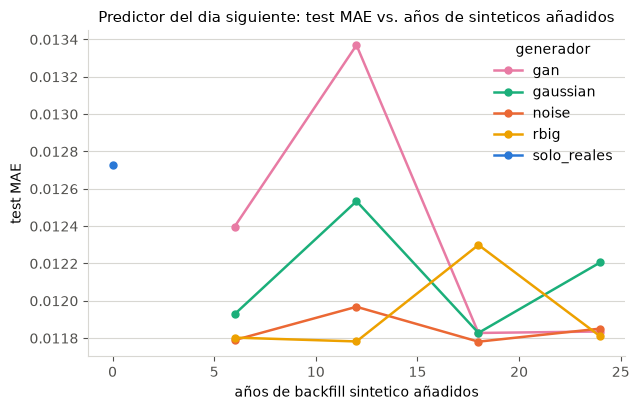

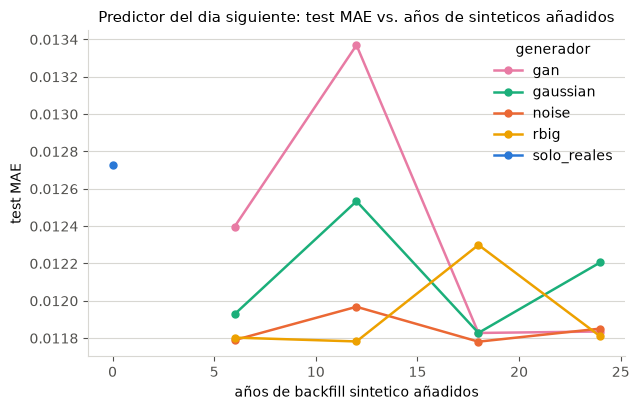

In [6]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "05_resultado_final_mae")
fig

## 4. Mejor generador a máxima profundidad sintética vs. calidad de
   reconstrucción de la distribución conjunta (notebook 02)

Si el generador que MEJOR reproduce la distribución conjunta real
(`dist_frobenius_corr` más bajo) es también el que da mejor MAE final, es
una señal fuerte de que la calidad del generador —y no solo la cantidad
de datos sintéticos— importa.

In [7]:
synth_max = results["synth_years"].max()
final_depth = (
    results[results["synth_years"] == synth_max]
    .set_index("generator")[["mae", "mse", "pct_synth"]]
    .join(corr_quality, how="left")
    .sort_values("mae")
)
final_depth.to_csv(config.TABLES_DIR / "05_tabla_generador_final.csv")
final_depth

,mae,mse,pct_synth,dist_frobenius_corr
generator,,,,
rbig,0.011809,0.000254,0.83814,0.243140
gan,0.011836,0.000254,0.83814,1.644512
noise,0.011851,0.000253,0.83814,0.249979
gaussian,0.012206,0.000269,0.83814,0.178185


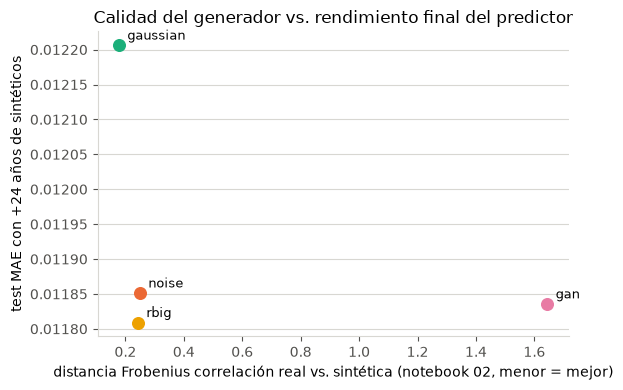

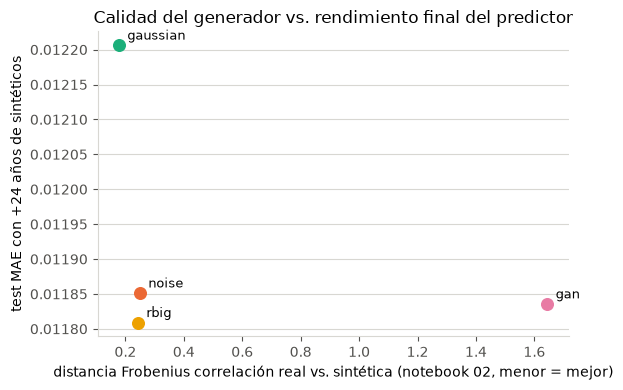

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, row in final_depth.iterrows():
    ax.scatter(row["dist_frobenius_corr"], row["mae"], s=70, color=pl.color_for(name), label=name)
    ax.annotate(name, (row["dist_frobenius_corr"], row["mae"]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)
ax.set_xlabel("distancia Frobenius correlación real vs. sintética (notebook 02, menor = mejor)")
ax.set_ylabel(f"test MAE con +{synth_max} años de sintéticos")
ax.set_title("Calidad del generador vs. rendimiento final del predictor")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "05_calidad_generador_vs_mae")
fig

## 5. Precisión direccional (¿acierta el signo del retorno?) y desglose
   por banco

El MAE mide error de MAGNITUD; para un "predictor de precios" también
importa si acierta la DIRECCIÓN (sube/baja) — 0.5 = tan bueno como una
moneda. Y el MAE por banco (notebook 04, misma idea que el bloque final
de `Taller_con_Datos_SP500_promedio.ipynb`) evita que la comparación
quede dominada por los bancos de mayor volatilidad (ver notebook 01).

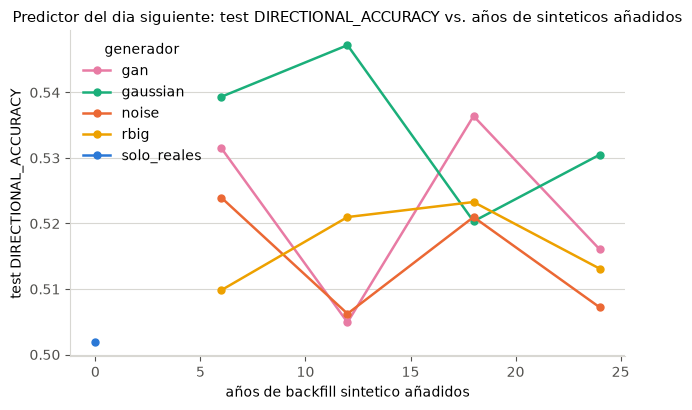

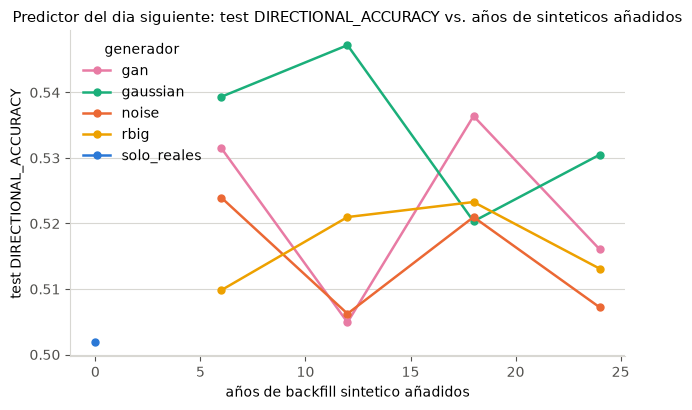

In [9]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "05_precision_direccional")
fig

In [10]:
mae_por_banco = pd.read_csv(config.TABLES_DIR / "04_mae_por_banco.csv", index_col=0)
mae_por_banco.round(5)

,noise,gaussian,rbig,gan,solo_reales
ticker,,,,,
BAC,0.01110,0.01157,0.01096,0.01100,0.01177
WFC,0.01380,0.01386,0.01375,0.01383,0.01424
JPM,0.01165,0.01215,0.01162,0.01159,0.01239
C,0.01492,0.01510,0.01495,0.01495,0.01524
HBAN,0.01344,0.01410,0.01354,0.01353,0.01457
USB,0.01090,0.01129,0.01079,0.01084,0.01176
TFC,0.01171,0.01164,0.01142,0.01140,0.01222
KEY,0.01181,0.01249,0.01184,0.01189,0.01302
RF,0.01200,0.01240,0.01204,0.01192,0.01311


## 6. Continuidad del empalme real/sintético por generador (notebook 03)

In [11]:
empalme.round(3)

,mean,std
generador,,
gan,1.301,0.118
gaussian,1.169,0.115
noise,1.196,0.092
rbig,1.174,0.098


## 7. Resumen para el README / presentación

Esta celda imprime, en texto, el resumen que debe copiarse (o citarse) en
el README y en las diapositivas de resultados.

In [12]:
mejor_generador = final_depth["mae"].idxmin()
mejora_mejor = mejora_pct.loc[synth_max, mejor_generador]
print(
    f"- MAE solo con la ventana real (sin sintéticos): {baseline_mae:.5f}\n"
    f"- Mejor generador con +{synth_max} años de sintéticos: {mejor_generador} "
    f"(MAE {final_depth.loc[mejor_generador, 'mae']:.5f}, "
    f"{mejora_mejor:+.1f}% vs. solo reales)\n"
    f"- % de días con volatilidad sintética con +{synth_max} años añadidos: "
    f"{final_depth.loc[mejor_generador, 'pct_synth']:.1%}\n"
)

- MAE solo con la ventana real (sin sintéticos): 0.01273
- Mejor generador con +24 años de sintéticos: rbig (MAE 0.01181, +7.2% vs. solo reales)
- % de días con volatilidad sintética con +24 años añadidos: 83.8%

